# Machine Learning Model for Webpage Information

## Imports

In [1]:
from sklearn.ensemble import RandomForestClassifier

%run "../utils/notebook_utils.py"
%run "../utils/feature_categories.py"

## Relevant Webpage Features

In [2]:
# Combines all webpage-related features into a single set
WEBPAGE_FEATURES = HTML_FEATURES | MEDIA_FEATURES | JAVASCRIPT_FEATURES | CONTENT_METADATA_FEATURES

# Base data frame
data_frame = generate_sub_data_frame(
    WEBPAGE_FEATURES
)

# Removes all features that are constant
CONSTANT_FEATURES = data_frame.loc[:, (data_frame.nunique() == 1)].columns
WEBPAGE_FEATURES.difference_update(CONSTANT_FEATURES)

# Regenerates data frame with relevant features
data_frame = generate_sub_data_frame(
    WEBPAGE_FEATURES
)

WEBPAGE_FEATURES

{'domain_in_title',
 'domain_with_copyright',
 'empty_title',
 'external_favicon',
 'iframe',
 'links_in_tags',
 'login_form',
 'nb_extCSS',
 'nb_hyperlinks',
 'onmouseover',
 'popup_window',
 'ratio_extHyperlinks',
 'ratio_extMedia',
 'ratio_intHyperlinks',
 'ratio_intMedia',
 'right_clic',
 'safe_anchor'}

## Correlation Matrix

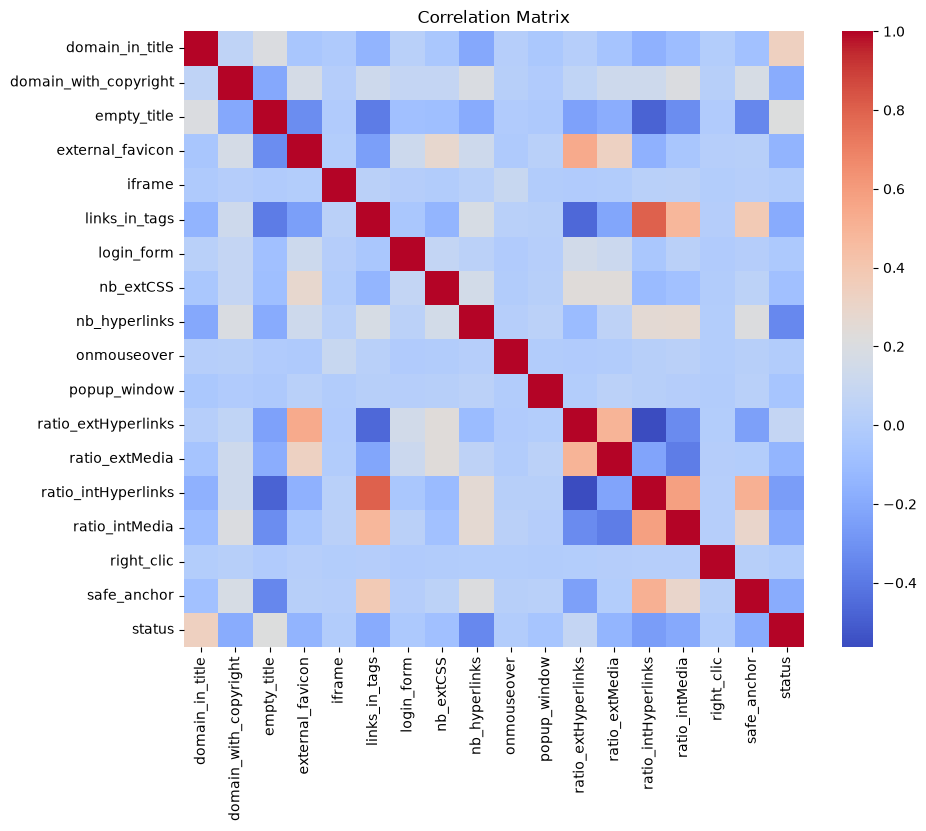

In [3]:
frame_correlation_matrix(data_frame, annotate=False)

## Random Forest Model

In [4]:
MODEL_FILE_NAME = "random_forest_webpage"
MODEL_TITLE = "Random Forest (Webpage Content Model)"

random_forest = RandomForestClassifier(random_state=41)
test_model(random_forest, MODEL_FILE_NAME, data_frame)


Training Report:
              precision    recall  f1-score   support

           0       0.99      0.97      0.98      3829
           1       0.97      1.00      0.98      3829

    accuracy                           0.98      7658
   macro avg       0.98      0.98      0.98      7658
weighted avg       0.98      0.98      0.98      7658


Test Report:
              precision    recall  f1-score   support

           0       0.88      0.89      0.89      1886
           1       0.89      0.88      0.89      1886

    accuracy                           0.89      3772
   macro avg       0.89      0.89      0.89      3772
weighted avg       0.89      0.89      0.89      3772



,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",41
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [5]:
save_stage_metrics(
    MODEL_TITLE,
    "Used Webpage Features",
    MODEL_FILE_NAME,
    set(data_frame.columns),
    random_forest
)

## Feature Importances

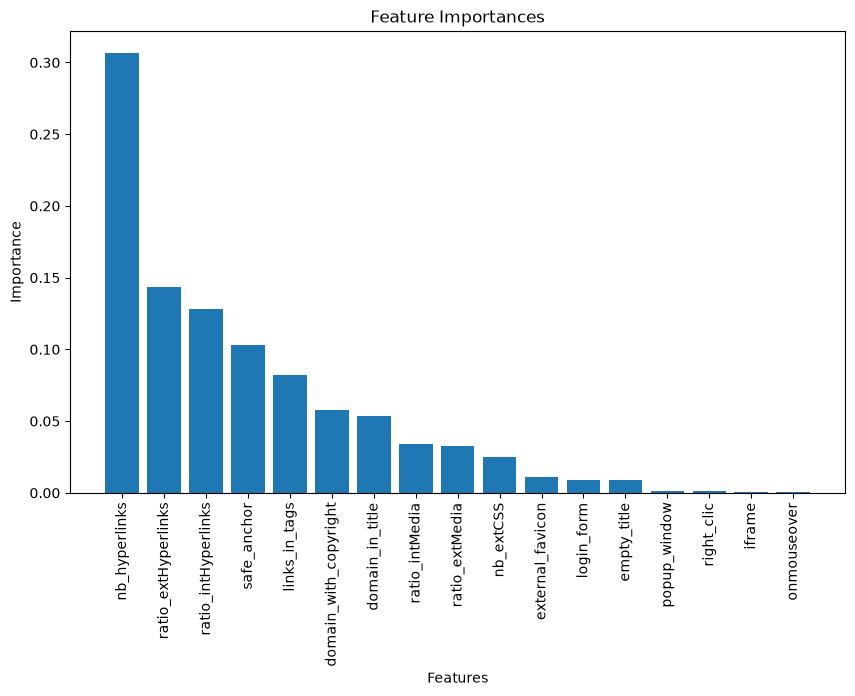

In [6]:
plot_feature_importance(random_forest)